In [13]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langgraph.graph import END, StateGraph,add_messages
from typing import Annotated, TypedDict
from langchain_ollama import ChatOllama

llm = ChatOllama(model='qwen3:1.7b')

generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a twitter techie influencer assistant tasked with writing excellent twitter posts."
            " Generate the best twitter post possible for the user's request."
            " If the user provides critique, respond with a revised version of your previous attempts.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

reflection_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a viral twitter influencer grading a tweet. Generate critique and recommendations for the user's tweet."
            "Always provide detailed recommendations, including requests for length, virality, style, etc.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

generation_chain = generation_prompt | llm
reflection_chain = reflection_prompt | llm

class SimpleState(TypedDict):
    messages: Annotated[list,add_messages]

In [14]:
def generate_node(state: SimpleState):
    response = generation_chain.invoke({
        "messages": state["messages"]
    })

    return {
        "messages": response
    }

def reflection_node(state: SimpleState):
    response = reflection_chain.invoke({
        "messages": state["messages"]
    })

    return {
        "messages": response
    }

def should_continue(state: SimpleState):
    if len(state["messages"]) > 2:
        return END
    return "reflect"

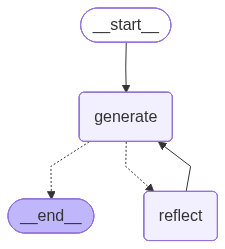

In [15]:
# Setup Graph
builder = StateGraph(SimpleState)

# Register Nodes
builder.add_node("generate",generate_node)
builder.add_node("reflect",reflection_node)

builder.set_entry_point("generate")

builder.add_conditional_edges("generate",
                              should_continue,
                              {
                                    "reflect": "reflect",
                                    END: END
                              })

builder.add_edge("reflect","generate")
app = builder.compile()
app

In [17]:
from langchain_core.messages import HumanMessage

result = app.invoke(
    {
        "messages": [
            HumanMessage(content="AI Agents taking over content creation")
        ]
    }
)

print("\nFinal Messages:")
for i,m in enumerate(result["messages"]):
    print(f"{i}: {m.type.upper()}: {m.content[:100]}...")


Final Messages:
0: HUMAN: AI Agents taking over content creation...
1: AI: 🚀 **AI is already rewriting the rules of content creation!** 🚀  

From blog posts to videos, AI is g...
2: AI:   

---

**Recommendations for Virality & Impact:**  
1. **Length:**  
   - **Expand the post to 100...
3: AI:   

---  
**Ready to go viral?** Let me know how you’d like to format it (video, blog, Twitter threa...
